plot_model_performance notebook
- Generates key visualizations to assess FALCON model performance,  namely hold-out test results and learning curves.
- Ensure the <u>Python 3.11 kernel (falcon-env)</u> is selected.
- Run configuration and functions before plotting
- Note: This script requires pre-trained models generated from run_FALCON.py.

In [20]:
### Required Run Parameters ### 

RUN_NAME = "PLGA_PEC_80" #Name of folder from which to load the model
cell_type = "Release D30" #Cell type of model to load 

### Configuration ###

In [21]:
#import statements 
import pickle 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
from scipy import stats
import pandas as pd

In [22]:
#load the model training pipeline results
model_path = f'../output/{RUN_NAME}/{cell_type}/'
with open(f'{model_path}Pipeline_dict.pkl', 'rb') as file:
    pipeline_results = pickle.load(file)

### Functions ###

In [23]:
def plot_predictions(pipeline, pred = None, exp = None, normalized = True, model_name = None, correlations = True):
    
    ######### Hold Out Validation Pred vs Exp. Plots ########

    if pred is None and exp is None:
        #Get Predictions
        model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']
        data = pipeline['Model_Selection']['Best_Model']['Predictions']

        experimental = data['Experimental_Transfection']
        predicted = data['Predicted_Transfection']
    else:
        experimental = exp
        predicted = pred

    experimental = pd.Series(np.asarray(experimental).reshape(-1), dtype=float)
    predicted = pd.Series(np.asarray(predicted).reshape(-1), dtype=float)

    if not normalized:
        output_scaler = pipeline['Data_preprocessing'].get('Output_Scaler')
        if output_scaler is None:
            raise ValueError("Cannot plot non-normalized values because Output_Scaler is missing from the pipeline.")

        experimental = pd.Series(
            output_scaler.inverse_transform(experimental.to_numpy().reshape(-1, 1)).reshape(-1)
        )
        predicted = pd.Series(
            output_scaler.inverse_transform(predicted.to_numpy().reshape(-1, 1)).reshape(-1)
        )

    if normalized:
        lower_lim = -0.05
        upper_lim = 1.15
        ticks = np.linspace(0, 1, 5)
    else:
        all_values = np.concatenate([experimental.to_numpy(), predicted.to_numpy()])
        value_range = all_values.max() - all_values.min()
        padding = max(value_range * 0.08, 1)
        lower_lim = all_values.min() - padding
        upper_lim = all_values.max() + padding
        ticks = np.linspace(lower_lim, upper_lim, 5)

    #Config Plot
    # sns.set_theme(font='Arial', font_scale= 2)
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12

    #Plot
    fig = plt.figure(figsize=(2.5,2.5), dpi = 200)
    cmap = sns.color_palette("hls", 8, as_cmap=False)

    # color hex code used for ramos is #c8def9
    # color hex code used for thp1 is #FFC080

    reg = sns.regplot(x = experimental, 
                        y = predicted,
                        marker='.',
                        scatter_kws={"color": '#c8def9', "edgecolor": "black",
                                    "alpha": 0.8, "s":200}, 
                        line_kws={"color": "black", "linestyle":'--'})

    #Annotate with correlations
    if correlations:
        pearsons = stats.pearsonr(predicted, experimental)
        spearman = stats.spearmanr(predicted, experimental)

        plt.annotate("r = {:.2f}".format(pearsons[0]), xy=(0.1, 0.9), xycoords="axes fraction",fontsize = "16")
        plt.annotate("ρ = {:.2f}".format(spearman[0]), xy=(0.1, 0.8), xycoords="axes fraction",fontsize = "16")

    #Labels
    plt.ylabel(f'Predicted {cell_type}')
    plt.xlabel(f'Experimental {cell_type}')

    reg.set(xlim=(lower_lim, upper_lim), xticks=ticks, ylim=(lower_lim, upper_lim), yticks=ticks)
    if not normalized:
        reg.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
        reg.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
        reg.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}"))
        reg.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}"))
    plt.xlim(lower_lim, upper_lim)
    plt.ylim(lower_lim, upper_lim)

    #Ticks
    reg.tick_params(colors='black', which='both')
    reg.tick_params(bottom=True, left=True)
    reg.axes.yaxis.label.set_color('black')
    reg.axes.xaxis.label.set_color('black')
    # reg.set_title("Hold-out Set Performance",weight="bold", fontsize = 15)

    # plt.tick_params(axis='both', which='major', labelsize=10)

    reg.spines['left'].set_color('black')
    reg.spines['bottom'].set_color('black')
    reg.spines['right'].set_visible(False)
    reg.spines['top'].set_visible(False)

    plt.grid(False)
    
def plot_learning_curve(pipeline):
    #Extract Results
    cell = pipeline['Cell']
    model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']

    mean_train_scores = pipeline['Learning_Curve']['Train_Error']
    mean_validation_scores = pipeline['Learning_Curve']['Valid_Error']
    train_valid_scores = pd.concat([mean_validation_scores, mean_train_scores], 
                                   ignore_index= True)

    # Plot configurations
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 12})

    fig, ax = plt.subplots(figsize = (3.4, 1.7), dpi = 200)

    line = sns.lineplot(data =  train_valid_scores,
                            x = "Train_size", 
                            y = 'Percent_Error', 
                            hue = "Score_Type", 
                            errorbar = "sd", 
                            linewidth = 3, 
                            palette=sns.color_palette("Set2" , 2))

    #line.set(xlim=(0, 540), xticks=np.linspace(0,540,6), ylim=(0, 20), yticks=np.arange(0,25,5))
    line.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes
    
    # add tick marks on x-axis or y-axis
    line.tick_params(bottom=True, left=True)
    
    # x-axis and y-axis label color
    line.axes.yaxis.label.set_color('black')
    line.axes.xaxis.label.set_color('black')

    #line.set_yticklabels(line.get_yticklabels())
    #line.set_xticklabels(line.get_xticklabels())

    line.spines['left'].set_color('black')
    line.spines['bottom'].set_color('black')        # x-axis and y-axis spines
    line.spines['right'].set_visible(False)
    line.spines['top'].set_visible(False)

    line.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes

    plt.grid(visible = False)
    plt.xlabel('Training size')
    plt.ylabel('Percent Error')
    plt.legend(fontsize = 'small', loc='upper left', bbox_to_anchor=(1.02, 1), framealpha = 0, borderaxespad=0)
    fig.subplots_adjust(right=0.72, bottom=0.22)


def get_prediction_frame(pipeline, normalized=True):
    model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']
    data = pipeline['Model_Selection']['Best_Model']['Predictions'].copy()

    experimental = pd.Series(np.asarray(data['Experimental_Transfection']).reshape(-1), dtype=float)
    predicted = pd.Series(np.asarray(data['Predicted_Transfection']).reshape(-1), dtype=float)

    if not normalized:
        output_scaler = pipeline['Data_preprocessing'].get('Output_Scaler')
        if output_scaler is None:
            raise ValueError("Cannot plot non-normalized values because Output_Scaler is missing from the pipeline.")
        experimental = pd.Series(
            output_scaler.inverse_transform(experimental.to_numpy().reshape(-1, 1)).reshape(-1)
        )
        predicted = pd.Series(
            output_scaler.inverse_transform(predicted.to_numpy().reshape(-1, 1)).reshape(-1)
        )

    return pd.DataFrame({
        'Formula label': data['Formula label'].to_numpy(),
        'Experimental': experimental,
        'Predicted': predicted,
        'Residual': experimental - predicted,
        'Model': model_name,
    })


def plot_residuals_vs_predicted(pipeline, normalized=False):
    residuals = get_prediction_frame(pipeline, normalized=normalized)
    model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']
    mae = np.mean(np.abs(residuals['Residual']))

    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12

    fig, ax = plt.subplots(figsize=(2.7, 2.3), dpi=200)
    sns.scatterplot(
        data=residuals,
        x='Predicted',
        y='Residual',
        marker='o',
        color='#c8def9',
        edgecolor='black',
        alpha=0.85,
        s=70,
        ax=ax,
    )
    ax.axhline(0, color='black', linestyle='--', linewidth=1)

    ax.annotate(f'MAE = {mae:.1f}' if not normalized else f'MAE = {mae:.2f}',
                xy=(0.05, 0.9), xycoords='axes fraction', fontsize=11)
    ax.set_xlabel(f'Predicted {cell_type}')
    ax.set_ylabel(f'Residual {cell_type}')
    ax.set_title(f'{model_name} residuals', fontsize=11)

    if not normalized:
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, integer=True))
        ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    return fig, ax, residuals


def get_cv_performance_frame(pipeline):
    rows = []
    nested_cv = pipeline['Model_Selection'].get('NESTED_CV', {})
    for model_name, model_results in nested_cv.items():
        cv_df = model_results.get('HP_tuning_df')
        if cv_df is None:
            continue
        for _, row in cv_df.iterrows():
            rows.append({
                'Model': model_name,
                'Fold': int(row['Iter (CV Fold)']),
                'Score Type': 'Validation MAE',
                'MAE': float(row['Valid Score (MAE)']),
            })
            rows.append({
                'Model': model_name,
                'Fold': int(row['Iter (CV Fold)']),
                'Score Type': 'Outer Test MAE',
                'MAE': float(row['Test Score (MAE)']),
            })
    return pd.DataFrame(rows)


def select_representative_models(cv_perf, include_model='kNN', n_models=5):
    ranked_models = (
        cv_perf.groupby('Model')['MAE']
        .median()
        .sort_values()
        .index
        .tolist()
    )
    if len(ranked_models) <= n_models:
        return ranked_models

    positions = np.linspace(0, len(ranked_models) - 1, n_models).round().astype(int)
    selected = [ranked_models[pos] for pos in positions]

    if include_model in ranked_models and include_model not in selected:
        selected[-1] = include_model

    return [model for model in ranked_models if model in selected]


def plot_cv_performance_distribution(pipeline, representative_only=True, include_model='kNN', n_models=5):
    cv_perf = get_cv_performance_frame(pipeline)
    if cv_perf.empty:
        raise ValueError('No nested CV performance results found in the pipeline.')

    model_order = (
        cv_perf.groupby('Model')['MAE']
        .median()
        .sort_values()
        .index
        .tolist()
    )

    if representative_only:
        model_order = select_representative_models(cv_perf, include_model=include_model, n_models=n_models)
        cv_perf = cv_perf[cv_perf['Model'].isin(model_order)].copy()

    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12

    width = max(4.8, 0.85 * len(model_order))
    fig, ax = plt.subplots(figsize=(width, 2.8), dpi=200)

    sns.boxplot(
        data=cv_perf,
        x='Model',
        y='MAE',
        hue='Score Type',
        order=model_order,
        showfliers=False,
        width=0.65,
        linewidth=1,
        palette=sns.color_palette('Set2', 2),
        ax=ax,
    )
    sns.stripplot(
        data=cv_perf,
        x='Model',
        y='MAE',
        hue='Score Type',
        order=model_order,
        dodge=True,
        jitter=0.08,
        alpha=0.75,
        size=4,
        linewidth=0.4,
        edgecolor='black',
        palette=sns.color_palette('Set2', 2),
        ax=ax,
    )

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:2],
        labels[:2],
        fontsize='small',
        framealpha=0,
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
    )
    ax.set_xlabel('Model')
    ax.set_ylabel('MAE')
    ax.set_title('Nested CV fold performance', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.subplots_adjust(right=0.72, bottom=0.28)
    return fig, ax, cv_perf



### Plotting ###

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


########## MODEL SELECTION PLOTTING


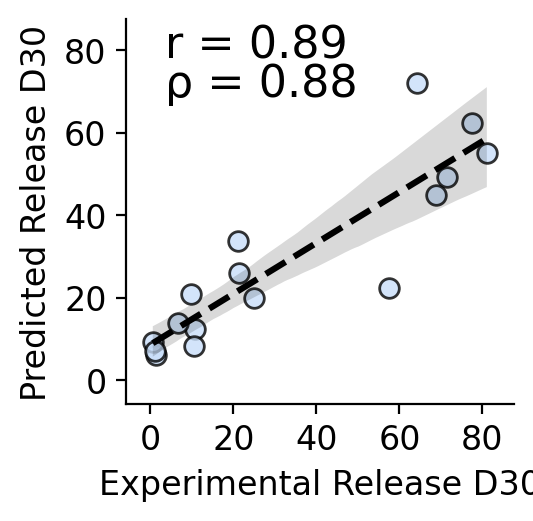

In [24]:
print()
print("########## MODEL SELECTION PLOTTING")
selected_model_name = pipeline_results["Model_Selection"]["Best_Model"]["Model_Name"]
plot_predictions(pipeline_results, normalized=False)

#example save statement
plt.savefig(model_path + f"{selected_model_name}_{cell_type}_predictions_raw.svg", dpi=600, format = "svg",transparent=True, bbox_inches = "tight")


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


########## LEARNING CURVE PLOTTING


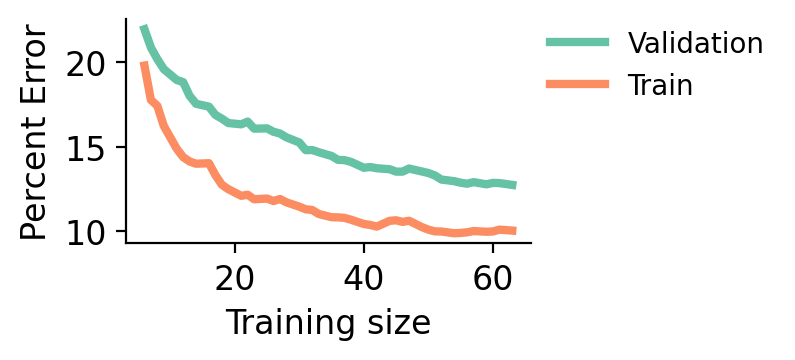

In [25]:
print()
print("########## LEARNING CURVE PLOTTING")
selected_model_name = pipeline_results["Model_Selection"]["Best_Model"]["Model_Name"]
plot_learning_curve(pipeline_results)

#example save statement
plt.savefig(model_path + f"{selected_model_name}_{cell_type}_learning_curve.svg", dpi=600, format = "svg",transparent=True, bbox_inches = "tight")



########## RESIDUALS VS PREDICTED PLOTTING


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

,Formula label,Experimental,Predicted,Residual,Model
0,NaN,68.783064,44.813262,23.969802,kNN
1,NaN,1.295124,6.003344,-4.708220,kNN
2,NaN,77.542640,62.398505,15.144135,kNN
3,NaN,0.571430,9.349720,-8.778290,kNN
4,NaN,25.058893,20.027466,5.031427,kNN
5,NaN,10.714925,12.504149,-1.789224,kNN
6,NaN,9.797468,20.966075,-11.168607,kNN
7,NaN,10.389937,8.408351,1.981585,kNN
8,NaN,71.565491,49.239616,22.325875,kNN
9,NaN,64.308509,72.176794,-7.868285,kNN


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

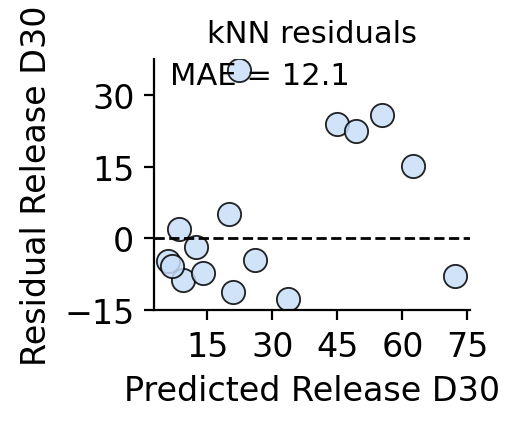

In [26]:
print()
print("########## RESIDUALS VS PREDICTED PLOTTING")
selected_model_name = pipeline_results["Model_Selection"]["Best_Model"]["Model_Name"]
residual_fig, residual_ax, residual_df = plot_residuals_vs_predicted(pipeline_results, normalized=False)

#example save statement
plt.savefig(model_path + f"{selected_model_name}_{cell_type}_residuals_vs_predicted_raw.svg", dpi=600, format = "svg",transparent=True, bbox_inches = "tight")
plt.savefig(model_path + f"{selected_model_name}_{cell_type}_residuals_vs_predicted_raw.png", dpi=300, transparent=True, bbox_inches = "tight")
residual_df



########## CROSS VALIDATION PERFORMANCE DISTRIBUTION


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

,Model,Fold,Score Type,MAE
0,kNN,5,Validation MAE,0.128189
1,kNN,5,Outer Test MAE,0.127321
2,kNN,1,Validation MAE,0.135736
3,kNN,1,Outer Test MAE,0.145075
4,kNN,3,Validation MAE,0.126281
5,kNN,3,Outer Test MAE,0.108435
6,kNN,4,Validation MAE,0.125692
7,kNN,4,Outer Test MAE,0.148348
8,kNN,2,Validation MAE,0.106972
9,kNN,2,Outer Test MAE,0.135095


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

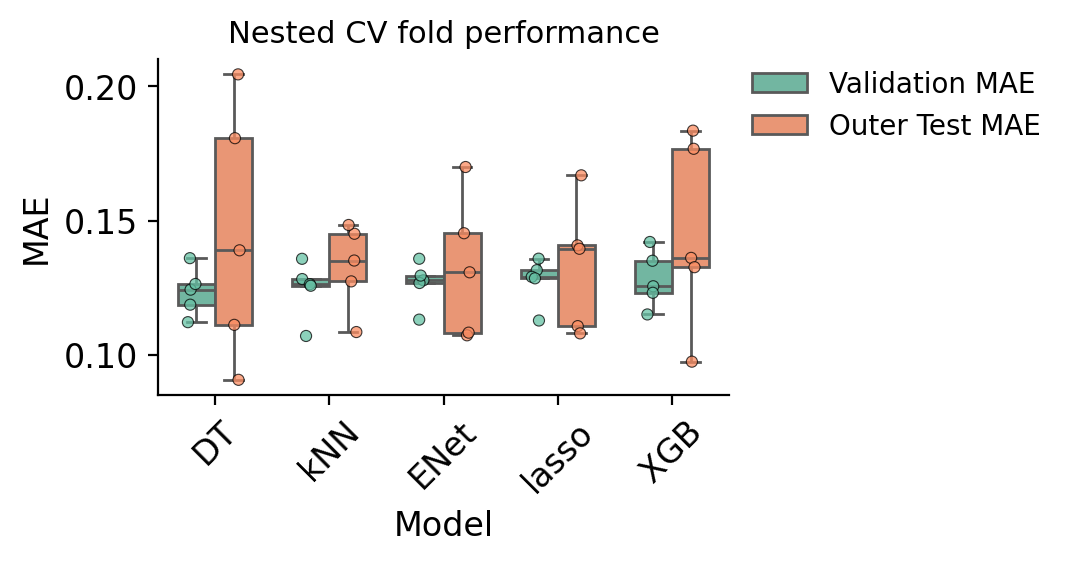

In [27]:
print()
print("########## CROSS VALIDATION PERFORMANCE DISTRIBUTION")
cv_fig, cv_ax, cv_performance_df = plot_cv_performance_distribution(pipeline_results, representative_only=True, include_model="kNN", n_models=5)

#example save statement
plt.savefig(model_path + f"{cell_type}_cv_fold_performance_distribution.svg", dpi=600, format = "svg",transparent=True, bbox_inches = "tight")
plt.savefig(model_path + f"{cell_type}_cv_fold_performance_distribution.png", dpi=300, transparent=True, bbox_inches = "tight")
cv_performance_df
